# Day 01 - 深度学习简介

## 学习目标
- 理解深度学习的基本概念

- 了解深度学习的常用模型

- 了解深度学习的预备数学知识

- 掌握安装pytorch的方法

- 理解张量的概念

- 掌握张量的基本创建方式

- 掌握创建线性和随机张量

- 掌握创建全 0/1 张量

- 掌握张量元素的类型转换

- 掌握张量 和 numpy 之间的相互转换


## 学习目标
- 理解深度学习的基本概念
    - **深度学习**（Deep Learning）是机器学习的分支，是一种以**人工神经网络为架构**，**对数据进行特征学习**的算法。
    - 深度学习中的“深度”是指在网络中使用多层。
- 了解深度学习的常用模型
    - **全连接神经网络（DNN / MLP）**： 适用于结构化数据（如表格数据）、简单分类与回归任务，比如商品销量预测、房价预测等。  
    - **卷积神经网络（CNN）**： 适用于处理图像与视觉任务，比如图像分类、目标检测、图像分割、人脸识别等。
    - **循环神经网络（RNN）**： 适用于顺序数据相关的任务，比如自然语言处理（NLP）、语音识别、时间序列预测。
    - **Transformer**： 当前主流模型，覆盖文本与图像等多领域，比如机器翻译、文本生成、对话系统、多模态任务。
    - **Diffusion（扩散模型）**： 当前图像/视频生成的主导架构（如 Stable Diffusion、Sora）。
- 了解深度学习的预备数学知识
    - 线性代数
        - **标量只有一个数值，称作0维/0D张量**
        - **向量为标量组成的列表，称作一维张量/1D张量**
        - **矩阵为多个向量组成的二维数组，称作二维张量/2D张量**
        - **$L_2$*范数*是向量元素平方和的平方根：**
    - 导数和微分
        - 导数是一个比值极限，可以将导数$f'(x)$解释为$f(x)$相对于$x$的 *瞬时* 变化率

- 掌握安装pytorch的方法
    - 安装miniconda/anaconda
    - 创建虚拟环境dl_project
    - 安装pytorch
    - 验证pytorch安装
- 理解张量的概念
    - **张量**（Tensor）是深度学习中的数据容器，**张量**可以描述任意数量轴的n维数组，n≥0
- 掌握张量的基本创建方式
    - torch.tensor 根据指定数据创建张量
    - torch.Tensor 根据形状创建张量, 其也可用来创建指定数据的张量
    - torch.IntTensor、torch.FloatTensor、torch.DoubleTensor 创建指定类型的张量
- 掌握创建线性和随机张量
    - torch.arange() 创建一个线性张量，一维张量
    - torch.linspace() 创建一个等差数列，一维张量
    - torch.rand() 创建一个随机数，形状任意
    - torch.randn() 创建一个随机数, 形状任意
    - torch.randint() 创建一个随机数, 形状任意
- 掌握创建全 0/1 张量
    - torch.ones 和 torch.ones_like 创建全1张量
    - torch.zeros 和 torch.zeros_like 创建全0张量
    - torch.full 和 torch.full_like 创建全为指定值张量
- 掌握张量元素的类型转换
    - data.type(torch支持的数据类型)
    - data.to(torch支持的数据类型)
    - data.half/double/float/short/int/long()
- 掌握张量 和 numpy 之间的相互转换
    - 张量 转 numpy数组对象：张量对象.numpy()
    - numpy数组对象 转 张量：torch.tensor(numpy数组对象)
    - 标量张量 转 python数值：张量对象.item()

In [ ]:
# 导包
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei']  # 微软雅黑
plt.rcParams['axes.unicode_minus'] = False            # 解决负号显示问题
# 设置设备
DEVICE = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)
print(f"当前设备：{DEVICE}")

当前设备：cuda


## 课程大纲
- 0. 预备数学知识
- 1. pytorch张量操作
- 2. ANN人工神经网络 Artifical neural network
- 3. CNN卷积神经网络 Convolutional neural network
- 4. RNN循环神经网络 Recurrent neural network

![lesson_title1117](assets/lesson_title1117.png)

## 1.什么是深度学习[知道]
**深度学习**（Deep Learning）是机器学习的分支，是一种以**人工神经网络为架构**，**对数据进行特征学习**的算法。深度学习中的形容词“深度”是指在网络中使用多层。

![1733800163423](assets/1733800163423.png)

深度学习核心思想是==通过模仿人脑的神经网络来处理和分析复杂的数据，从大量数据中自动提取复杂特征==，擅长处理高维数据，如图像、语音和文本。

![1733800312800](assets/1733800312800.png)

## 2.深度学习特点[知道]

- **多层非线性变换**：神经网络模型由多个层次组成，每一层都应用非线性激活函数对输入数据进行变换。较低的层级通常捕捉到简单的特征（如边缘、颜色等），而更高的层级则可以识别更复杂的模式（如物体或面部识别）。

- **自动特征提取**：与传统机器学习算法不同，深度学习能够从原始数据中自动提取特征，不需要人工特征工程。

- **大数据和计算能力**：神经网络模型通常需要大量的标注数据和强大的计算资源（如GPU）来进行训练。大数据和高性能计算使得深度学习在图像识别、自然语言处理等领域取得了显著突破。

- **可解释性差**：神经网络模型内部的运作机制相对不透明，被称为“黑箱”，难以解释模型的决策逻辑或过程。

## 3.常见的深度学习模型[了解]

- **全连接神经网络（DNN / MLP）**
  - 输入输出均为定长向量，多用于结构化数据的分类与回归。  
  - 在图像/文本任务中已很少单独使用，多作为基础组件。

- **卷积神经网络（CNN）**
  - 利用卷积核提取局部特征，是图像分类、检测、分割的经典主力。  
  - 工程部署中仍是最常用、最高效的视觉模型体系。

- **循环神经网络（RNN）**
  - 处理序列数据（时间序列、NLP），LSTM/GRU 能建模长依赖。  
  - 在大多数任务中已被 Transformer 取代。

- **Diffusion Models（扩散模型）**
  - 当前图像/视频生成的主导架构（如 Stable Diffusion、Sora）。  
  - 生成质量、稳定性和自由度全面优于 GAN。

- **Transformer（当今最主流架构）**
  - 通过自注意力捕获全局关系，是 NLP 的事实标准。  
  - 在视觉领域衍生出 ViT、Swin Transformer，并成为 LLM / VLM 的核心架构。

- **图神经网络（GNN）**
  - 处理图结构数据，如分子结构、社交网络、知识图谱。  
  - 典型模型：GCN、GAT、GraphSAGE，在药物发现与推荐系统中应用广泛。

- **深度强化学习（DRL）**
  - 将神经网络与强化学习结合，用于序列决策与控制。  
  - 典型方法：DQN、PPO；应用于 AlphaGo、机器人、自主驾驶等。

## 4.深度学习应用场景[了解]

- ==计算机视觉（Computer Vision）==

  - **图像分类**：将图像分为不同的类别。常用于人脸识别、物体检测等。
    - 自动标注社交媒体照片、医疗影像中的病变检测。
  - **目标检测（Object Detection）**：在图像或视频中定位并分类多个对象。
    - 自动驾驶中的行人检测、监控视频中的入侵检测。
  - **面部识别**：通过分析面部特征进行身份验证或分类。
    - 手机解锁、安防监控系统。

  - **图像生成**：基于输入生成新的图像，如风格转换、图像超分辨率等。
    - 艺术风格迁移、老旧照片修复。

- ==自然语言处理（Natural Language Processing, NLP）==

  - **机器翻译**：使用深度学习模型将一种语言的文本自动翻译成另一种语言。
    - Google翻译、实时语音翻译。
  - **情感分析**：分析文本中的情感倾向，如正面、负面或中性。
    - 社交媒体监控、产品评论分析。

  - **文本生成**：生成符合语法和语义的自然语言文本。
    - 自动写作助手、新闻生成。

  - **语音识别**：将语音转化为文字。
    - 智能助手（如Siri、Alexa）、自动字幕生成。
  - **聊天机器人（Chatbot）**：通过深度学习理解用户输入并生成合理的回应。
    - 客服机器人、虚拟助手（如GPT类模型）。

- ==推荐系统（Recommendation Systems）==

  - **电影、音乐推荐**：根据用户历史的评分和行为，推荐相关的电影、音乐或电视剧。
    - Netflix、Spotify的个性化推荐。
  - **电商推荐**：根据用户的购买历史和浏览习惯推荐商品。
    - 亚马逊、淘宝的商品推荐系统。
  - **社交媒体推荐**：分析用户的社交行为，推荐相关内容或朋友。
    - Facebook、Instagram的内容推荐。

  ...

![1733802918559](assets/1733802918559.png)

##  5.深度学习发展史[了解]

- 早期探索

  - 20世纪40年代：沃尔特·皮茨（Walter Pitts）和沃伦·麦卡洛克（Warren McCulloch）等开始模仿生物神经系统来构建计算模型，如McCulloch-Pitts神经元
  - 1958年：弗兰克·罗森布拉特（Frank Rosenblatt）提出感知器概念，能够进行简单的二分类任务
  - 1960年代末：出现了多层感知器（MLP），但当时由于计算能力和数据量的限制，这些模型的应用受到很大限制
  - 图灵测试：如果一台机器能够与人类展开对话（透过电传设备）而不被辨别出其机器身份，那么称这台机器具有智慧
- 挑战与瓶颈

  - 1986年：**反向传播算法（Backpropagation）的提出标志着神经网络研究的一个重要突破。杰弗里·辛顿（Geoffrey Hinton）和大卫·鲁梅尔哈特**（David Rumelhart）等人提出了反向传播算法，使得多层神经网络（即深层网络）能够通过梯度下降优化参数，解决复杂的非线性问题。
  - 虽然神经网络方法在一些领域表现不错，但由于计算资源的限制以及对复杂数据（如图像和语音）的处理能力较弱，深度学习未能广泛应用。此时，**支持向量机（SVM）**、**决策树**等传统机器学习方法成为主流。
- 复兴与突破

  - **2006年**：**杰弗里·辛顿**和其团队提出了**深度信念网络（DBN）**，标志着深度学习的复兴。他们引入了无监督预训练的技术，使得深层网络能够有效训练。这为深度学习的发展奠定了基础。
  - **2012年**：深度学习的一个重要突破是**AlexNet**的出现。**亚历克斯·克里泽夫斯基**（Alex Krizhevsky）在**ImageNet图像分类竞赛**中使用了一个深度卷积神经网络，显著提升了图像分类的精度，比传统方法提高了20%以上。AlexNet的成功标志着深度学习在计算机视觉领域的成功应用。
  - **2014年**：生成对抗网络（**GANs**）由**伊恩·古德费洛**（Ian Goodfellow）等人提出，开启了生成模型的新时代，能够生成非常逼真的图像、音频和视频。
  - **2015年**：**ResNet**（残差网络）由**何凯明**（Kaiming He）等提出，解决了深度网络中的梯度消失和梯度爆炸问题，允许训练极深的网络（如50层、152层），极大推动了深度学习在图像识别任务中的应用。
- 爆发期
  - **2016年：** Google AlphaGo 战胜李世石（人工智能第三次浪潮），AlphaGo 展现了深度强化学习（Deep Reinforcement Learning）在解决复杂问题上的巨大潜力，将其推向了公众视野。
  - **2017年：** 自然语言处理NLP的Transformer框架出现，奠定了后续预训练语言模型（如 BERT 和 GPT）的基础。
  - **2018年：** BERT和GPT的出现，基于Transformer架构的预训练语言模型的代表。
  - **2022年：** ChatGPT的出现，进入到大模型AIGC阶段，开启了 AI 与人交互的新模式，使人们可以更容易地使用 AI。

![1733811105932](assets/1733811105932.png)


## 6.扩展-预备的数学知识-理解

### 线性代数

- 标量

**标量只有一个数值，称作零维张量/0D张量**

下面的代码将实例化两个标量，并执行一些熟悉的算术运算，即加法、乘法、除法和指数。

In [ ]:
import torch

x = torch.tensor(3.0)
y = torch.tensor(2.0)

x + y, x-y, x * y, x / y, x**y

(tensor(5.), tensor(1.), tensor(6.), tensor(1.5000), tensor(9.))

- 向量

**向量可以被视为标量值组成的列表，称作一维张量/1D张量**

通过一维张量表示向量。

In [ ]:
x = torch.arange(5)
x

tensor([0, 1, 2, 3, 4])

在数学中，向量$\mathbf{x}$可以写为：

$$\mathbf{x} =\begin{bmatrix}x_{1}  \\x_{2}  \\ \vdots  \\x_{n}\end{bmatrix},$$

其中$x_1,\ldots,x_n$是向量的元素。在代码中，**通过张量的索引来访问任一元素**。


In [ ]:
x[3]

tensor(3)

- 矩阵

**多个向量组成的二维数组，称作二维张量/2D张量**

通常用粗体、大写字母来表示
（例如，$\mathbf{X}$、$\mathbf{Y}$和$\mathbf{Z}$），
表示具有两个轴的张量。

数学上，使用$\mathbf{A} \in \mathbb{R}^{m \times n}$
来表示矩阵$\mathbf{A}$，其由$m$行和$n$列的实值标量组成。
可以将任意矩阵$\mathbf{A} \in \mathbb{R}^{m \times n}$视为一个表格，
其中每个元素$a_{ij}$属于第$i$行第$j$列：

$$\mathbf{A}=\begin{bmatrix} a_{11} & a_{12} & \cdots & a_{1n} \\ a_{21} & a_{22} & \cdots & a_{2n} \\ \vdots & \vdots & \ddots & \vdots \\ a_{m1} & a_{m2} & \cdots & a_{mn} \\ \end{bmatrix}.$$

对于任意$\mathbf{A} \in \mathbb{R}^{m \times n}$，
$\mathbf{A}$的形状是（$m$,$n$）或$m \times n$。

**通过指定形状$m \times n$来创建矩阵**


In [ ]:
A = torch.arange(20).reshape(5, 4)
A

tensor([[ 0,  1,  2,  3],
        [ 4,  5,  6,  7],
        [ 8,  9, 10, 11],
        [12, 13, 14, 15],
        [16, 17, 18, 19]])

可以通过行索引（$i$）和列索引（$j$）来访问矩阵中的标量元素$a_{ij}$，
例如$[\mathbf{A}]_{ij}$。

In [ ]:
A[1,2]

tensor(6)

**矩阵的转置(transpose)** : 交换矩阵的行和列。
通常用$\mathbf{a}^\top$来表示矩阵的转置。


In [ ]:
A.T

tensor([[ 0,  4,  8, 12, 16],
        [ 1,  5,  9, 13, 17],
        [ 2,  6, 10, 14, 18],
        [ 3,  7, 11, 15, 19]])

- 张量

**深度学习中的数据容器，可以描述任意数量轴的n维数组, n≥0**

张量是描述具有任意数量轴的$n$维数组的通用方法。
例如，向量是一维张量，矩阵是二维张量。
张量用特殊字体的大写字母表示（例如，$\mathsf{X}$、$\mathsf{Y}$和$\mathsf{Z}$），
它们的索引机制（例如$x_{ijk}$和$[\mathsf{X}]_{1,2i-1,3}$）与矩阵类似。

比如图像数据，通常为3维张量，HWC格式的3个轴对应于高度height、宽度width，以及一个通道channel轴，用于表示颜色通道（红色、绿色和蓝色）。

In [ ]:
X = torch.arange(24).reshape(2, 3, 4)
X

tensor([[[ 0,  1,  2,  3],
         [ 4,  5,  6,  7],
         [ 8,  9, 10, 11]],

        [[12, 13, 14, 15],
         [16, 17, 18, 19],
         [20, 21, 22, 23]]])

- 张量的维度和形状

张量的维度用来表示张量具有的轴的数量。张量的某个轴的维数就是这个轴/维的长度。

|         | 概念 | 0D: 体重60                                     | 1D: 股价[10, 9, 8, 7, 6]                            | 2D: 多个股价[[10, 9, 8, 7, 6], [10, 9, 8, 7, 6]] | 3D: 单个图片HWC, 形状(32, 32, 3)                                   |
|-------------|----------------------------------------|---------------------------------|--------------------------------------------|--------------------------------------------|--------------------------------------------|
| 形状 Shape| 张量在每个轴的长度，描述了张量的结构。   |  `()`                | `(5)`|     `(2, 5)`       |      `(32, 32, 3)`      |
| 每个维度的长度 Length| 张量在某一维度的长度，表示该维度/轴的元素数。 | None | `5`       |       `2, 5`        |       `32, 32, 3`        |
| 维度/轴数 Dimension/Axes| 张量的维度数，即张量形状的长度，表示数据有几个轴。 | 0 |     1     |    2         |    3         |

In [ ]:
# 0D 张量（0轴）
tensor_0d = torch.tensor(3)
print("0D 张量:")
print(tensor_0d)
print(f"维度/轴数: {tensor_0d.ndimension()}")  # 输出: 0 （0 个轴）
print(f"形状: {tensor_0d.shape}")  # 输出: torch.Size([]) 
print()

0D 张量:
tensor(3)
维度/轴数: 0
形状: torch.Size([])



In [ ]:
# 1D 张量（一轴）
tensor_1d = torch.tensor([1, 2, 3, 4])
print("1D 张量:")
print(tensor_1d)
print(f"维度/轴数: {tensor_1d.ndimension()}")  # 输出: 1 （1 个轴）
print(f"形状: {tensor_1d.shape}")  # 输出: torch.Size([4]) 
print(f"第一轴的长度: {tensor_1d.size(0)}")  # 输出: 4 （第一轴的长度）
print()

1D 张量:
tensor([1, 2, 3, 4])
维度/轴数: 1
形状: torch.Size([4])
第一轴的长度: 4



In [ ]:
# 2D 张量（两轴）
tensor_2d = torch.tensor([[1, 2, 3], [4, 5, 6]])
print("2D 张量:")
print(tensor_2d)
print(f"维度/轴数: {tensor_2d.ndimension()}")  # 输出: 2 （2 个轴）
print(f"形状: {tensor_2d.shape}")  # 输出: torch.Size([2, 3]) 
print(f"第一轴的长度: {tensor_2d.size(0)}")  # 输出: 2 （第一轴的长度）
print(f"第二轴的长度: {tensor_2d.size(1)}")  # 输出: 3 （第二轴的长度）
print()

2D 张量:
tensor([[1, 2, 3],
        [4, 5, 6]])
维度/轴数: 2
形状: torch.Size([2, 3])
第一轴的长度: 2
第二轴的长度: 3



In [ ]:
# 3D 张量（三轴）
tensor_3d = torch.randn(2, 3, 4)  # 随机生成一个形状为 (2, 3, 4) 的张量
print("3D 张量:")
print(tensor_3d)
print(f"维度/轴数: {tensor_3d.ndimension()}")  # 输出: 3 （3 个轴）
print(f"形状: {tensor_3d.shape}")  # 输出: torch.Size([2, 3, 4]) 
print(f"第一轴的长度: {tensor_3d.size(0)}")  # 输出: 2 （第一轴的长度）
print(f"第二轴的长度: {tensor_3d.size(1)}")  # 输出: 3 （第二轴的长度）
print(f"第三轴的长度: {tensor_3d.size(2)}")  # 输出: 4 （第三轴的长度）

3D 张量:
tensor([[[ 0.4968, -0.9117,  1.1406, -0.4478],
         [ 1.2144,  1.0395,  0.3268,  1.0089],
         [ 0.2423, -0.6523,  1.4988,  0.1857]],

        [[ 0.7483, -0.4628, -0.9472, -0.2087],
         [-0.6753, -0.7449,  0.4467,  0.3950],
         [-0.4283, -0.2210,  1.5081,  1.5544]]])
维度/轴数: 3
形状: torch.Size([2, 3, 4])
第一轴的长度: 2
第二轴的长度: 3
第三轴的长度: 4


- 范数

向量的*范数*是表示一个向量有多大。

**$L_2$*范数*是向量元素平方和的平方根：**

(**$$\|\mathbf{x}\|_2 = \sqrt{\sum_{i=1}^n x_i^2},$$**)

其中，在$L_2$范数中常常省略下标$2$，也就是说$\|\mathbf{x}\|$等同于$\|\mathbf{x}\|_2$。
在代码中，我们可以按如下方式计算向量的$L_2$范数。

注意：深度学习中的L2范数，是指平方项的和，没有开根号。

In [ ]:
u = torch.tensor([5, 12.])
torch.norm(u)

tensor(13.)

**$L_1$范数，它表示为向量元素的绝对值之和：**

(**$$\|\mathbf{x}\|_1 = \sum_{i=1}^n \left|x_i \right|.$$**)

与$L_2$范数相比，$L_1$范数受异常值的影响较小。


In [ ]:
torch.abs(u).sum()

tensor(17.)

$L_p$范数：

$$\|\mathbf{x}\|_p = \left(\sum_{i=1}^n \left|x_i \right|^p \right)^{1/p}$$

[**矩阵**]$\mathbf{X} \in \mathbb{R}^{m \times n}$ **的*Frobenius范数*（Frobenius norm）是矩阵元素平方和的平方根：**

**$$\|\mathbf{X}\|_F = \sqrt{\sum_{i=1}^m \sum_{j=1}^n x_{ij}^2}$$**


In [ ]:
torch.norm(torch.ones((9, 9)))

tensor(9.)

### 导数和微分

假设有一个函数$f: \mathbb{R} \rightarrow \mathbb{R}$，其输入和输出都是标量。
**$f$的*导数*被定义为:**

**$$f'(x) = \lim_{h \rightarrow 0} \frac{f(x+h) - f(x)}{h}$$**

如果$f'(a)$存在，则称$f$在$a$处是*可微*（differentiable）的。
如果$f$在一个区间内的每个数上都是可微的，则此函数在此区间中是可微的。
我们可以将导数$f'(x)$解释为$f(x)$相对于$x$的*瞬时*（instantaneous）变化率。
注意：
- 导函数$f'(x)$表示函数$f(x)$在一个区间的导数。
- 导数$f'(a)$表示导函数$f'(x)$在$a$处的数值。
- 深度学习中，导数也称作*梯度*， 导数可能是 导函数 或 导数，根据语义区分。

为了更好地解释导数，让我们做一个实验。
(**定义$u=f(x)=3x^2-4x$**)如下：


In [ ]:
# %matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
from matplotlib_inline import backend_inline

def f(x):
    return 3 * x ** 2 - 4 * x   # 6x - 4，2

**通过令$x=1$并让$h$接近$0$，**(**$\frac{f(x+h)-f(x)}{h}$的数值结果接近$2$**)


In [ ]:
def numerical_lim(f, x, h):
    return (f(x + h) - f(x)) / h

h = 0.1
for i in range(6):
    print(f'h={h:.6f}, numerical limit={numerical_lim(f, 1, h):.6f}')
    h *= 0.1

h=0.100000, numerical limit=2.300000
h=0.010000, numerical limit=2.030000
h=0.001000, numerical limit=2.003000
h=0.000100, numerical limit=2.000300
h=0.000010, numerical limit=2.000030
h=0.000001, numerical limit=2.000003


导数符号，
给定$y=f(x)$，其中$x$和$y$分别是函数$f$的自变量和因变量。以下表达式是等价的：

$$f'(x) = y' = \frac{dy}{dx} = \frac{df}{dx} = \frac{d}{dx} f(x) = Df(x) = D_x f(x),$$

其中符号$\frac{d}{dx}$和$D$是*微分运算符*，表示*微分*操作。
常见函数求微分：

* $C' = 0$（$C$是一个常数）
* $(x^n)' = nx^{n-1}$（$n$是任意实数）
* $(e^x)' = e^x$
* $(\ln(x))' = 1/x$


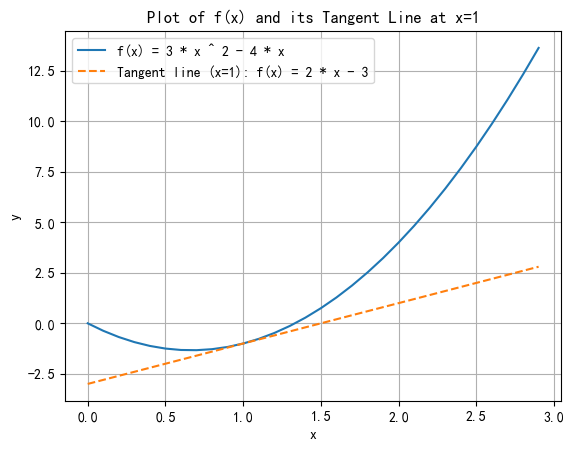

In [ ]:
# 创建 x 数据
x = np.arange(0, 3, 0.1)

# 绘制 f(x) 和切线
plt.plot(x, f(x), label="f(x) = 3 * x ^ 2 - 4 * x")  # 绘制函数 f(x)
plt.plot(x, 2 * x - 3, label='Tangent line (x=1): f(x) = 2 * x - 3', linestyle='--')  # 绘制切线

# 添加标签、标题和图例
plt.xlabel('x')
plt.ylabel('y')
plt.title('Plot of f(x) and its Tangent Line at x=1')
plt.legend()
plt.grid()
plt.show()

## 7. 安装PyTorch

- 安装miniconda/anaconda

下载地址 https://www.anaconda.com/download/success

- 初始化conda

In [ ]:
# conda init --all

- 创建虚拟环境dl_project

In [ ]:
# conda create -n dl_project python=3.10
# conda activate dl_project

- 安装pytorch

选择CPU版本/GPU版本，
参考网址：https://pytorch.org/get-started/locally/

如果没有GPU，直接安装CPU版本的pytorch

In [ ]:
# CPU
# pip3 install torch torchvision

如果有英伟达的GPU，首先检查支持的CUDA版本，然后安装对应CUDA版本的pytorch
- 建议：如果GPU显存 >= 4G，则安装GPU版本的pytorch，否则直接安装CPU版本的pytorch

In [ ]:
# 首先查看本机支持的CUDA版本,向下兼容
!nvidia-smi

Tue Mar  3 10:23:04 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 576.65                 Driver Version: 576.65         CUDA Version: 12.9     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 5070 ...  WDDM  |   00000000:01:00.0  On |                  N/A |
| N/A   51C    P4             12W /  115W |    1195MiB /   8151MiB |      5%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
# GPU, 比如CUDA12.6，要根据CUDA版本选择对应的安装命令，参考
# pip3 install torch torchvision --index-url https://download.pytorch.org/whl/cu126

- 验证pytorch安装

In [ ]:
import torch

print("pytorch版本: ", torch.__version__)
print("能否使用GPU: ", torch.cuda.is_available())

if torch.cuda.is_available():
    print(f"GPU型号: {torch.cuda.get_device_name()}")  # 获取 GPU 名称

pytorch版本:  2.10.0.dev20251114+cu128
能否使用GPU:  True
GPU型号: NVIDIA GeForce RTX 5070 Laptop GPU


## 8. 什么是PyTorch？

PyTorch是Facebook开发的深度学习框架，具有以下特点：
- **类似于NumPy的张量计算**
  - PyTorch中的基本数据结构是张量（Tensor），它与NumPy中的数组类似，但PyTorch的张量具有GPU加速的能力（通过CUDA），这使得深度学习模型能够高效地在GPU上运行。
- **自动微分系统**
  - PyTorch提供了强大的**自动微分**功能（`autograd`模块），能够自动计算模型中每个参数的梯度。
  - 自动微分使得梯度计算过程变得简洁和高效，并且支持复杂的模型和动态计算图。
- **深度学习库**
  - PyTorch提供了一个名为**torch.nn**的子模块，用于构建神经网络。它包括了大量的预构建的层（如全连接层、卷积层、循环神经网络层等），损失函数（如交叉熵、均方误差等），以及优化算法（如SGD、Adam等）。
  - `torch.nn.Module`是PyTorch中构建神经网络的基础类，用户可以通过继承该类来定义自己的神经网络架构。

- **动态计算图**
  - PyTorch使用动态计算图机制，允许在运行时构建和修改模型结构，具有更高的灵活性，适合于研究人员进行实验和模型调试。
- **GPU加速（CUDA支持）**
  - PyTorch提供对GPU的良好支持，能够在NVIDIA的CUDA设备上高效地进行计算。用户只需要将数据和模型转移到GPU上，PyTorch会自动优化计算过程。
  - 通过简单的`tensor.to(device)`方法，可以轻松地将模型和数据从CPU转移到GPU或从一个GPU转移到另一个GPU。
- **跨平台支持**
  - PyTorch支持在多种硬件平台（如CPU、GPU、TPU等）上运行，并且支持不同操作系统（如Linux、Windows、macOS）以及分布式计算环境（如多GPU、分布式训练）。

## 9. 什么是PyTorch张量？

> 张量是PyTorch中的核心数据抽象

- PyTorch中的张量就是元素为同一种数据类型的多维数组，类似NumPy数组。

- PyTorch中，张量以"类"的形式封装起来，对张量的一些运算、处理的方法（数值计算、矩阵操作、自动求导）被封装在类中。

![1733817329667](assets/1733817329667.png)

## day01_01_张量的基本创建方式

- torch.tensor()
- torch.Tensor()

> - 张量的数据类型有
>
>   ![1662778155632](assets/1662778155632.png)
>
> - 张量中默认的数据类型是**float32(torch.FloatTensor)**

- torch.tensor 根据指定数据创建张量

- torch.Tensor 根据形状创建张量, 其也可用来创建指定数据的张量

- torch.IntTensor、torch.FloatTensor、torch.DoubleTensor 创建指定类型的张量

张量的属性
- type: 对象的类型
- shape: 张量的形状
- dtype: 数据类型
- device: 存储位置(CPU/GPU)
- requires_grad: 是否需要梯度

In [ ]:
    张量的创建的基本方式
张量
    pytorch中存储数据的一种容器，元素必须是数值，元素类型必须相同
设计到的API：
    torch.tensor 根据指定数据创建张量
    torch.Tensor 根据形状创建张量, 也可用来创建指定数据的张量
    torch.IntTensor、torch.FloatTensor、torch.DoubleTensor 创建指定类型的张量

注意：
    torch.Tensor比torch.tensor多一个功能，可以指定形状来创建张量

要掌握的：
    torch.tensor(数据,数据类型torch.float32)

"""

# 导包
import torch

# 1.定义函数，演示torch.tensor创建张量
def demo01():
    # 1.创建0维张量/0D张量，也就是标量
    t1 = torch.tensor(1)
    print(f"0D-t1:{t1}, shape: {t1.shape}, type: {type(t1)}, dtype: {t1.dtype}")
    # 2.创建1维张量/1D张量
    t2 = torch.tensor([1,2,3])
    print(f"1D-t2:{t2}, shape: {t2.shape}, type: {type(t2)}, dtype: {t2.dtype}")
    # 3.创建2维张量/2D张量
    t3 = torch.tensor([[1,2,3],[4,5,6]],dtype=torch.float32)    # 形状(2,3)
    print(f"2D-t3:{t3}, shape: {t3.shape}, type: {type(t3)}, dtype: {t3.dtype}")
    # 4.创建3维张量/3D张量
    t4 = torch.tensor([[[1,2,3],[4,5,6]]])  # 形状(1,2,3)
    print(f"3D-t4:{t4}, shape: {t4.shape}, type: {type(t4)}, dtype: {t4.dtype}")
    # # 5.创建指定形状的张量，(3,4)
    # t5 = torch.tensor(3,)
    # print(f"指定形状-t5:{t5}, shape: {t5.shape}")

# 2.定义函数，演示torch.Tensor创建张量
def demo02():
    # 1.创建0维张量/0D张量，也就是标量
    t1 = torch.Tensor(1)
    print(f"0D-t1:{t1}, shape: {t1.shape}, type: {type(t1)}, dtype: {t1.dtype}")
    # 2.创建1维张量/1D张量
    t2 = torch.Tensor([1,2,3])
    print(f"1D-t2:{t2}, shape: {t2.shape}, type: {type(t2)}, dtype: {t2.dtype}")
    # 3.创建2维张量/2D张量
    t3 = torch.Tensor([[1,2,3],[4,5,6]])    # 形状(2,3)
    print(f"2D-t3:{t3}, shape: {t3.shape}, type: {type(t3)}, dtype: {t3.dtype}")
    # 4.创建3维张量/3D张量
    t4 = torch.Tensor([[[1,2,3],[4,5,6]]])  # 形状(1,2,3)
    print(f"3D-t4:{t4}, shape: {t4.shape}, type: {type(t4)}, dtype: {t4.dtype}")
    # 5.创建指定形状的张量，(3,4)
    t5 = torch.Tensor(3,4)
    print(f"指定形状-t5:{t5}, shape: {t5.shape}")

# 3.定义函数，演示torch.IntTensor(Int64)、torch.FloatTensor(Float32)、torch.DoubleTensor(Float64)创建张量
def demo03():
    # 1.创建0维张量/0D张量，也就是标量
    t1 = torch.IntTensor(1)
    print(f"0D-t1:{t1}, shape: {t1.shape}, type: {type(t1)}, dtype: {t1.dtype}")
    # 2.创建1维张量/1D张量
    t2 = torch.IntTensor([1,2,3])
    print(f"1D-t2:{t2}, shape: {t2.shape}, type: {type(t2)}, dtype: {t2.dtype}")
    # 3.创建2维张量/2D张量
    t3 = torch.FloatTensor([[1,2,3],[4,5,6]])    # 形状(2,3)
    print(f"2D-t3:{t3}, shape: {t3.shape}, type: {type(t3)}, dtype: {t3.dtype}")
    # 4.创建3维张量/3D张量
    t4 = torch.DoubleTensor([[[1,2,3],[4,5,6]]])  # 形状(1,2,3)
    print(f"3D-t4:{t4}, shape: {t4.shape}, type: {type(t4)}, dtype: {t4.dtype}")
    # 5.创建指定形状的张量，(3,4)
    t5 = torch.Tensor(3,4)
    print(f"指定形状-t5:{t5}, shape: {t5.shape}")

# 4.定义函数，演示张量的属性
# type:对象类型，shape:形状，dtype:数据类型，device:设备，requires_grad:是否开启梯度计算
def demo04():
    # 1.创建一个张量，(2,3)
    # t1 = torch.tensor([[1,2,3],[4,5,6]],dtype=torch.float32,device="cuda",requires_grad=True)
    t1 = torch.tensor([[1,2,3],[4,5,6]])
    print(f"t1:{t1}, type: {type(t1)}, shape: {t1.shape}, dtype: {t1.dtype}, device: {t1.device}, requires_grad: {t1.requires_grad}")
    # dtype: int32
    # device:cpu
    # requires_grad: False
    ...

# 测试
if __name__ == '__main__':
    demo01()
    demo02()
    demo03()
    demo04()

In [ ]:
    torch.tensor 根据指定数据创建张量
    torch.Tensor 根据形状创建张量, 也可用来创建指定数据的张量
    torch.IntTensor、torch.FloatTensor、torch.DoubleTensor 创建指定类型的张量

注意：
    torch.Tensor比torch.tensor多一个功能，可以指定形状来创建张量

要掌握的：
    torch.tensor(数据,数据类型torch.float32)

"""

# 导包
import torch

# 1.定义函数，演示torch.tensor创建张量
def demo01():
    # 1.创建0维张量/0D张量，也就是标量
    t1 = torch.tensor(1)
    print(f"0D-t1:{t1}, shape: {t1.shape}, type: {type(t1)}, dtype: {t1.dtype}")
    # 2.创建1维张量/1D张量
    t2 = torch.tensor([1,2,3])
    print(f"1D-t2:{t2}, shape: {t2.shape}, type: {type(t2)}, dtype: {t2.dtype}")
    # 3.创建2维张量/2D张量
    t3 = torch.tensor([[1,2,3],[4,5,6]],dtype=torch.float32)    # 形状(2,3)
    print(f"2D-t3:{t3}, shape: {t3.shape}, type: {type(t3)}, dtype: {t3.dtype}")
    # 4.创建3维张量/3D张量
    t4 = torch.tensor([[[1,2,3],[4,5,6]]])  # 形状(1,2,3)
    print(f"3D-t4:{t4}, shape: {t4.shape}, type: {type(t4)}, dtype: {t4.dtype}")
    # # 5.创建指定形状的张量，(3,4)
    # t5 = torch.tensor(3,)
    # print(f"指定形状-t5:{t5}, shape: {t5.shape}")

# 2.定义函数，演示torch.Tensor创建张量
def demo02():
    # 1.创建0维张量/0D张量，也就是标量
    t1 = torch.Tensor(1)
    print(f"0D-t1:{t1}, shape: {t1.shape}, type: {type(t1)}, dtype: {t1.dtype}")
    # 2.创建1维张量/1D张量
    t2 = torch.Tensor([1,2,3])
    print(f"1D-t2:{t2}, shape: {t2.shape}, type: {type(t2)}, dtype: {t2.dtype}")
    # 3.创建2维张量/2D张量
    t3 = torch.Tensor([[1,2,3],[4,5,6]])    # 形状(2,3)
    print(f"2D-t3:{t3}, shape: {t3.shape}, type: {type(t3)}, dtype: {t3.dtype}")
    # 4.创建3维张量/3D张量
    t4 = torch.Tensor([[[1,2,3],[4,5,6]]])  # 形状(1,2,3)
    print(f"3D-t4:{t4}, shape: {t4.shape}, type: {type(t4)}, dtype: {t4.dtype}")
    # 5.创建指定形状的张量，(3,4)
    t5 = torch.Tensor(3,4)
    print(f"指定形状-t5:{t5}, shape: {t5.shape}")

# 3.定义函数，演示torch.IntTensor(Int64)、torch.FloatTensor(Float32)、torch.DoubleTensor(Float64)创建张量
def demo03():
    # 1.创建0维张量/0D张量，也就是标量
    t1 = torch.IntTensor(1)
    print(f"0D-t1:{t1}, shape: {t1.shape}, type: {type(t1)}, dtype: {t1.dtype}")
    # 2.创建1维张量/1D张量
    t2 = torch.IntTensor([1,2,3])
    print(f"1D-t2:{t2}, shape: {t2.shape}, type: {type(t2)}, dtype: {t2.dtype}")
    # 3.创建2维张量/2D张量
    t3 = torch.FloatTensor([[1,2,3],[4,5,6]])    # 形状(2,3)
    print(f"2D-t3:{t3}, shape: {t3.shape}, type: {type(t3)}, dtype: {t3.dtype}")
    # 4.创建3维张量/3D张量
    t4 = torch.DoubleTensor([[[1,2,3],[4,5,6]]])  # 形状(1,2,3)
    print(f"3D-t4:{t4}, shape: {t4.shape}, type: {type(t4)}, dtype: {t4.dtype}")
    # 5.创建指定形状的张量，(3,4)
    t5 = torch.Tensor(3,4)
    print(f"指定形状-t5:{t5}, shape: {t5.shape}")

# 4.定义函数，演示张量的属性
# type:对象类型，shape:形状，dtype:数据类型，device:设备，requires_grad:是否开启梯度计算
def demo04():
    # 1.创建一个张量，(2,3)
    # t1 = torch.tensor([[1,2,3],[4,5,6]],dtype=torch.float32,device="cuda",requires_grad=True)
    t1 = torch.tensor([[1,2,3],[4,5,6]])
    print(f"t1:{t1}, type: {type(t1)}, shape: {t1.shape}, dtype: {t1.dtype}, device: {t1.device}, requires_grad: {t1.requires_grad}")
    # dtype: int32
    # device:cpu
    # requires_grad: False
    ...

# 测试
if __name__ == '__main__':
    demo01()
    demo02()
    demo03()
    demo04()

## day01_02_创建线性和随机张量

- torch.arange()
- torch.linspace()
- torch.rand()
- torch.randn()
- torch.randint()

In [ ]:
"""
演示
    创建 线性 和 随机张量
设计到的API:
    torch.arange() 和 torch.linspace() 创建线性张量
    torch.manual_seed() 设置随机种子
    torch.rand/randn() 创建随机浮点类型张量
    torch.randint(low, high, size=()) 创建随机整数类型张量

需要掌握的：
    torch.arange()
    torch.linspace()
    torch.manual_seed()
    torch.randint(low, high, size=())

"""

# 导包
import torch

# 1.定义函数，使用torch.arange() 和 torch.linspace()创建线性张量
def demo01():
    # 1.使用torch.arange()创建一个从0到9的线性张量
    t1 = torch.arange(0,10)
    print(f"t1:{t1}, shape: {t1.shape}, dtype: {t1.dtype}")
    # 2.使用torch.linspace()创建一个从0到9的线性张量
    t2 = torch.linspace(0,9,10)
    print(f"t2:{t2}, shape: {t2.shape}, dtype: {t2.dtype}")
# 2.定义函数，演示 创建随机张量
def demo02():
    # 0.设置随机种子
    # torch.random.manual_seed(28)
    torch.manual_seed(28)
    # 1.使用torch.rand创建一个随机张量，(3,5)
    t1 = torch.rand(3,5)
    print(f"t1:{t1}, shape: {t1.shape}, dtype: {t1.dtype}") # (3,5)
    # 2.使用torch.randn创建一个随机张量，(3,5)
    t2 = torch.randn(3,5)
    print(f"t2:{t2}, shape: {t2.shape}, dtype: {t2.dtype}")
    # 3.使用torch.randint创建一个随机整数张量，(3,5)
    t3 = torch.randint(0,10,(3,5))
    print(f"t3:{t3}, shape: {t3.shape}, dtype: {t3.dtype}")
    # 4.打印当前随机种子
    print(f"当前随机种子:{torch.initial_seed()}")

# 测试
if __name__ == '__main__':
    demo01()
    demo02()

t1:tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]), shape: torch.Size([10]), dtype: torch.int64
t2:tensor([0., 1., 2., 3., 4., 5., 6., 7., 8., 9.]), shape: torch.Size([10]), dtype: torch.float32
t1:tensor([[0.6275, 0.7307, 0.6773, 0.7381, 0.9916],
        [0.0473, 0.7836, 0.6494, 0.0149, 0.3280],
        [0.8142, 0.4852, 0.7695, 0.7390, 0.4993]]), shape: torch.Size([3, 5]), dtype: torch.float32
t2:tensor([[ 0.7097,  1.1189,  1.0106,  1.2861,  1.2156],
        [ 1.3547, -0.2655,  0.6406,  0.2314, -1.0052],
        [-0.8960,  2.8955,  0.6155,  0.7220,  0.9727]]), shape: torch.Size([3, 5]), dtype: torch.float32
t3:tensor([[5, 2, 5, 0, 7],
        [2, 6, 1, 8, 2],
        [9, 9, 2, 3, 8]]), shape: torch.Size([3, 5]), dtype: torch.int64
当前随机种子:28


## day01_03_创建全0_1_指定值张量

- torch.ones()
- torch.ones_like()
- torch.zeros()
- torch.zeros_like()
- torch.full()
- torch.full_like()

In [ ]:
"""
演示
    创建 全0、全1、指定值 张量
涉及到的API:
    torch.zeros 和 torch.zeros_like 创建全0张量
    torch.ones 和 torch.ones_like 创建全1张量
    torch.full 和 torch.full_like 创建全为指定值张量

要掌握：
    torch.zeros
用处：
    网络参数初始化，偏置参数初始化
"""

# 导包
import torch

# 1.定义函数，演示创建全0张量
def demo01():
    # 1.使用torcn.zeros创建全0张量，(3,4)
    t1 = torch.zeros(3,4)
    print(f"t1:{t1}, shape: {t1.shape}, dtype: {t1.dtype}")
    # 2.创建一个随机张量，(3,5)
    t2 = torch.randn(3,5)
    print(f"t2:{t2}, shape: {t2.shape}, dtype: {t2.dtype}")
    # 3.使用torch.zeros_like创建相同形状的全0张量
    t3 = torch.zeros_like(t2)   # (3,5)
    print(f"t3:{t3}, shape: {t3.shape}, dtype: {t3.dtype}")

# 2.定义函数，演示创建全1张量
def demo02():
    # 1.使用torcn.ones创建全1张量，(3,4)
    t1 = torch.ones(3,4)
    print(f"t1:{t1}, shape: {t1.shape}, dtype: {t1.dtype}")
    # 2.创建一个随机张量，(3,5)
    t2 = torch.randn(3,5)
    print(f"t2:{t2}, shape: {t2.shape}, dtype: {t2.dtype}")
    # 3.使用torch.ones_like创建相同形状的全1张量
    t3 = torch.ones_like(t2)   # (3,5)
    print(f"t3:{t3}, shape: {t3.shape}, dtype: {t3.dtype}")

# 3.定义函数，演示创建指定值张量
def demo03():
    # 1.使用torcn.full创建指定值张量，(3,4)
    t1 = torch.full((3,4),10)
    print(f"t1:{t1}, shape: {t1.shape}, dtype: {t1.dtype}")
    # 2.创建一个随机张量，(3,5)
    t2 = torch.randn(3,5)
    print(f"t2:{t2}, shape: {t2.shape}, dtype: {t2.dtype}")
    # 3.使用torch.full_like创建相同形状的指定值张量
    t3 = torch.full_like(t2,10)   # (3,5)
    print(f"t3:{t3}, shape: {t3.shape}, dtype: {t3.dtype}")
    
# 测试
if __name__ == '__main__':
    demo01()
    demo02()
    demo03()

t1:tensor([[0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.]]), shape: torch.Size([3, 4]), dtype: torch.float32
t2:tensor([[ 1.0008,  0.9901,  1.1953,  0.3355, -1.3303],
        [ 0.7373,  0.3204,  1.0588,  0.7245, -0.1745],
        [-1.1522, -1.0215, -0.2300, -0.1846,  0.9408]]), shape: torch.Size([3, 5]), dtype: torch.float32
t3:tensor([[0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.]]), shape: torch.Size([3, 5]), dtype: torch.float32
t1:tensor([[1., 1., 1., 1.],
        [1., 1., 1., 1.],
        [1., 1., 1., 1.]]), shape: torch.Size([3, 4]), dtype: torch.float32
t2:tensor([[ 0.1173,  0.3012, -1.2187,  0.3630, -0.2570],
        [-0.2466,  0.2393,  0.5575,  0.9406,  0.4120],
        [-1.1098, -0.1115,  1.6410, -0.2346, -0.1227]]), shape: torch.Size([3, 5]), dtype: torch.float32
t3:tensor([[1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1.]]), shape: torch.Size([3, 5]), dtype: torch.float32
t1:tensor([[10, 

## day01_04_张量元素的类型转换

- .to()
- .type()
- .half/double/float/short/int/long()

In [ ]:
"""
演示
    张量元素类型的转换

设计到的API:
    data.to(torch.float32)
    data.type(torch.DoubleTensor)
    data.half/double/float/short/int/long()
需要掌握：
    data.to(dtype,device)
    data.type(dtype)

"""

# 导包
import torch

# 设置设备
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"device:{device}")
# 1.定义函数，演示 张量的元素类型转换
def demo01():
    # 1.创建张量时，指定元素类型
    t1 = torch.tensor([[1,2,3],[4,5,6]], dtype=torch.float32)
    print(f"t1:{t1}, shape: {t1.shape}, dtype: {t1.dtype}, device: {t1.device}")
    # 2.使用data.to实现张量元素类型转换
    t2 = t1.to(dtype=torch.float64)
    print(f"t2:{t2}, shape: {t2.shape}, dtype: {t2.dtype}, device: {t2.device}")
    t2 = t2.to(device)
    print(f"t2:{t2}, shape: {t2.shape}, dtype: {t2.dtype}, device: {t2.device}")
    # 3.使用data.type实现张量元素类型转换
    t3 = t1.type(dtype=torch.float64)
    print(f"t3:{t3}, shape: {t3.shape}, dtype: {t3.dtype}, device: {t3.device}")
    # 4.使用data.double实现张量元素类型转换
    t4 = t1.double()
    print(f"t4:{t4}, shape: {t4.shape}, dtype: {t4.dtype}, device: {t4.device}")
    ...

# 测试
if __name__ == '__main__':
    demo01()

device:cuda
t1:tensor([[1., 2., 3.],
        [4., 5., 6.]]), shape: torch.Size([2, 3]), dtype: torch.float32, device: cpu
t2:tensor([[1., 2., 3.],
        [4., 5., 6.]], dtype=torch.float64), shape: torch.Size([2, 3]), dtype: torch.float64, device: cpu
t2:tensor([[1., 2., 3.],
        [4., 5., 6.]], device='cuda:0', dtype=torch.float64), shape: torch.Size([2, 3]), dtype: torch.float64, device: cuda:0
t3:tensor([[1., 2., 3.],
        [4., 5., 6.]], dtype=torch.float64), shape: torch.Size([2, 3]), dtype: torch.float64, device: cpu
t4:tensor([[1., 2., 3.],
        [4., 5., 6.]], dtype=torch.float64), shape: torch.Size([2, 3]), dtype: torch.float64, device: cpu


## day01_05_张量和numpy之间相互转换
- 张量 转 numpy数组对象：张量对象.numpy()
- numpy数组对象 转 张量：torch.tensor(numpy数组对象)
- 标量张量 转 python数值：张量对象.item()

In [ ]:
"""
演示
    张量 和 numpy数组 之间的相互转换，以及 只有一个数值的张量 转换为 python数值

涉及到的API:
    张量 转 numpy数组对象：
        张量对象.numpy()      共享内存，浅拷贝
        张量对象.numpy().copy() 不共享内存，深拷贝
    numpy数组对象 转 张量：
        torch.from_numpy(numpy数组对象)  共享内存，浅拷贝
        torch.tensor(numpy数组对象)       不共享内存，深拷贝
    一个数值的张量 转 python数值：
        张量对象.item()

需要掌握：
    张量 转 numpy数组对象：张量对象.numpy()
    numpy数组对象 转 张量：torch.tensor(numpy数组对象)
    一个数值的张量 转 python数值：张量对象.item()

"""

# 导包
import torch

# 1.定义函数，演示 张量 和 numpy数组之间 的相互转换
def demo01():
    # 0.设置随机种子
    torch.manual_seed(28)
    # 1.创建一个随机张量，(3,4)
    t1 = torch.randn(3,4)
    print(f"t1:{t1}, shape: {t1.shape}, dtype: {t1.dtype}")
    # # 2.使用张量对象.numpy(),将张量转为numpy数组
    # n1 = t1.numpy()
    # print(f"n1:{n1}, shape: {n1.shape}, dtype: {n1.dtype}")
    # # 3.演示 共享内存，改变n1
    # n1[0,0] = 100
    # print(f"n1:{n1}, shape: {n1.shape}, dtype: {n1.dtype}")
    # print(f"t1:{t1}, shape: {t1.shape}, dtype: {t1.dtype}")
    # 4.使用张量对象.numpy().copy(),将张量转为numpy数组
    n2 = t1.numpy().copy()
    print(f"n2:{n2}, shape: {n2.shape}, dtype: {n2.dtype}")
    # 5.演示 不共享内存，改变n2
    n2[0,0] = 200
    print(f"n2:{n2}, shape: {n2.shape}, dtype: {n2.dtype}")
    print(f"t1:{t1}, shape: {t1.shape}, dtype: {t1.dtype}")
    # 6.使用torch.from_numpy(numpy数组对象)，将numpy数组转为张量，共享内存，浅拷贝，心灵感应
    t2 = torch.from_numpy(n2)
    print(f"t2:{t2}, shape: {t2.shape}, dtype: {t2.dtype}")
    t2[0,0] = 10
    print(f"t2:{t2}, shape: {t2.shape}, dtype: {t2.dtype}")
    print(f"n2:{n2}, shape: {n2.shape}, dtype: {n2.dtype}")
    # 7.使用torch.tensor(numpy数组对象)，将numpy数组转为张量,不共享内存,深拷贝，彻底分家
    t3 = torch.tensor(n2)
    print(f"t3:{t3}, shape: {t3.shape}, dtype: {t3.dtype}")
    t3[0,0] = 20
    print(f"t3:{t3}, shape: {t3.shape}, dtype: {t3.dtype}")
    print(f"n2:{n2}, shape: {n2.shape}, dtype: {n2.dtype}")
    # 8.演示 一个数值的张量 转 python数值，张量对象.item()
    t4 = torch.tensor([True])
    print(f"t4:{t4}, shape: {t4.shape}, dtype: {t4.dtype}")
    a4 = t4.item()
    print(f"a4:{a4}, type: {type(a4)}")
    ...

# 测试
if __name__ == '__main__':
    demo01()

t1:tensor([[ 1.0333,  0.1315,  0.7220, -0.3254],
        [ 0.8793,  0.8175,  1.7920,  2.6727],
        [-1.1943, -0.8866, -0.3745, -0.5265]]), shape: torch.Size([3, 4]), dtype: torch.float32
n2:[[ 1.0332977   0.13147365  0.7219881  -0.32538113]
 [ 0.87932754  0.81754243  1.7920128   2.6727133 ]
 [-1.1942909  -0.88659436 -0.37448838 -0.52645123]], shape: (3, 4), dtype: float32
n2:[[ 2.0000000e+02  1.3147365e-01  7.2198808e-01 -3.2538113e-01]
 [ 8.7932754e-01  8.1754243e-01  1.7920128e+00  2.6727133e+00]
 [-1.1942909e+00 -8.8659436e-01 -3.7448838e-01 -5.2645123e-01]], shape: (3, 4), dtype: float32
t1:tensor([[ 1.0333,  0.1315,  0.7220, -0.3254],
        [ 0.8793,  0.8175,  1.7920,  2.6727],
        [-1.1943, -0.8866, -0.3745, -0.5265]]), shape: torch.Size([3, 4]), dtype: torch.float32
t2:tensor([[ 2.0000e+02,  1.3147e-01,  7.2199e-01, -3.2538e-01],
        [ 8.7933e-01,  8.1754e-01,  1.7920e+00,  2.6727e+00],
        [-1.1943e+00, -8.8659e-01, -3.7449e-01, -5.2645e-01]]), shape: torch.Si

## day01_06.张量的基本运算

In [ ]:
"""
演示
    张量的基本运算，也就是 + - * / -
涉及到的API:
    add、sub、mul、div、neg
    add_、sub_、mul_、div_、neg_（其中带下划线的版本会修改原数据）,inplace=True
需要掌握：
    + - * /
注意：
    1.张量 和 标量的运算：就是张量的每个元素和这个标量进行运算
    2.pytorch可以通用的API：Tensor.X = torch.X(Tensor,)

"""

# 导包
import torch

# 1.定义函数，演示 张量的基本运算
def demo01():
    # 0.设置随机种子
    torch.manual_seed(28)
    # 1.定义一个张量，(3,4)
    t1 = torch.randint(0,10,(3,4))
    print(f"t1:{t1}, shape: {t1.shape}, dtype: {t1.dtype}")
    # 2.演示 +
    t2 = t1 + 1
    # t2 = t1.add(1)
    # t2 = torch.add(t1,1)
    # t2 = t1.add_(1)
    print(f"t2:{t2}, shape: {t2.shape}, dtype: {t2.dtype}")
    print(f"t1:{t1}, shape: {t1.shape}, dtype: {t1.dtype}")
    # 3.演示 -
    # t2 = t1 - 1
    t2 = t1.sub(1)
    # t2 = torch.sub(t1,1)
    # t2 = t1.sub_(1)
    print(f"t2:{t2}, shape: {t2.shape}, dtype: {t2.dtype}")
    print(f"t1:{t1}, shape: {t1.shape}, dtype: {t1.dtype}")
    # 4.演示 *
    # t2 = t1 * 2
    t2 = t1.mul(2)
    # t2 = torch.mul(t1,2)
    # t2 = t1.mul_(2)
    print(f"t2:{t2}, shape: {t2.shape}, dtype: {t2.dtype}")
    print(f"t1:{t1}, shape: {t1.shape}, dtype: {t1.dtype}")
    # 5.演示 /
    t2 = t1 / 2
    # t2 = t1.div(2)
    # t2 = torch.div(t1,2)
    # t2 = t1.div_(2)
    print(f"t2:{t2}, shape: {t2.shape}, dtype: {t2.dtype}")
    print(f"t1:{t1}, shape: {t1.shape}, dtype: {t1.dtype}")
    # 6.演示 取负 -
    t2 = - t1
    # t2 = t1.neg(2)
    # t2 = torch.neg(t1,2)
    # t2 = t1.neg_(2)
    print(f"t2:{t2}, shape: {t2.shape}, dtype: {t2.dtype}")
    print(f"t1:{t1}, shape: {t1.shape}, dtype: {t1.dtype}")
    ...

# 测试
if __name__ == '__main__':
    demo01()

t1:tensor([[7, 9, 3, 8],
        [8, 4, 1, 3],
        [6, 8, 3, 3]]), shape: torch.Size([3, 4]), dtype: torch.int64
t2:tensor([[ 8, 10,  4,  9],
        [ 9,  5,  2,  4],
        [ 7,  9,  4,  4]]), shape: torch.Size([3, 4]), dtype: torch.int64
t1:tensor([[7, 9, 3, 8],
        [8, 4, 1, 3],
        [6, 8, 3, 3]]), shape: torch.Size([3, 4]), dtype: torch.int64
t2:tensor([[6, 8, 2, 7],
        [7, 3, 0, 2],
        [5, 7, 2, 2]]), shape: torch.Size([3, 4]), dtype: torch.int64
t1:tensor([[7, 9, 3, 8],
        [8, 4, 1, 3],
        [6, 8, 3, 3]]), shape: torch.Size([3, 4]), dtype: torch.int64
t2:tensor([[14, 18,  6, 16],
        [16,  8,  2,  6],
        [12, 16,  6,  6]]), shape: torch.Size([3, 4]), dtype: torch.int64
t1:tensor([[7, 9, 3, 8],
        [8, 4, 1, 3],
        [6, 8, 3, 3]]), shape: torch.Size([3, 4]), dtype: torch.int64
t2:tensor([[3.5000, 4.5000, 1.5000, 4.0000],
        [4.0000, 2.0000, 0.5000, 1.5000],
        [3.0000, 4.0000, 1.5000, 1.5000]]), shape: torch.Size([3, 4]),

## 常见面试题

### 1. 深度学习与传统机器学习的主要区别
  - **特征工程**：
    - 传统机器学习依赖人来做特征工程（feature engineering），需要特定的领域知识。
    - 深度学习可以自动从原始数据中提取特征，无需人参与。
  - **多层非线性网络**：
    - 传统机器学习模型相对简单，如线性回归、SVM等。
    - 深度学习模型通常由多层非线性神经网络组成，参数量大，表达能力更强。
  - **数据需求**：
    - 传统机器学习在小数据集上也能表现较好。
    - 深度学习通常需要大量数据才能发挥优势。
  - **计算资源**：
    - 深度学习需要更多计算资源（GPU/TPU）。
    - 传统机器学习对硬件要求较低，通常CPU就可以。
  - **可解释性差**：
    - 深度学习模型类似“黑箱”，难以解释模型内部的具体决策过程。这对某些应用场景来说是一个挑战。
    - 传统机器学习：模型结构更简单，可解释性更强。

---

### 2. 常见的深度学习模型及应用场景
  - **全连接神经网络（DNN / MLP）**  
    - **应用**：适用于结构化数据（如表格数据）、简单分类与回归任务，比如商品销量预测、房价预测等。  
  - **卷积神经网络（CNN）**
    - **应用**：处理图像与视觉任务，比如图像分类、目标检测、图像分割、人脸识别等。
  - **循环神经网络（RNN）**
    - **应用**：顺序数据相关的任务，比如自然语言处理（NLP）、语音识别、时间序列预测。
  - **Transformer**
    - **应用**：当前主流模型，覆盖文本与图像等多领域，比如机器翻译、文本生成、对话系统、多模态任务。
  - **Diffusion（扩散模型）**
    - **应用**：当前图像/视频生成的主导架构（如 Stable Diffusion、Sora）。

---

### 3. 数学中的矩阵是深度学习中的几维张量？
  - 数学中的矩阵对应深度学习中的 **2维张量**。

---

### 4. 数组 `[3, 4]` 的 L2 范数
  - L2 范数（欧几里得范数）计算公式为平方和再开根号：

$
\|[3,4]\|_2 = \sqrt{3^2 + 4^2} = \sqrt{9 + 16} = \sqrt{25} = 5
$


## 代码作业

- 1.使用torch.tensor()、torch.arange()和torch.randn()分别创建一个形状为(3, 4)的张量，并打印。
- 2.创建一个形状为(5,10)的全0张量 和 全1张量，并打印。
- 3.使用torch.randint()创建一个形状为(3, 4)的随机整数张量,并将元素类型转换为torch.float32，并打印。
- 4.使用torch.rand()创建一个形状为(3, 4)的张量，然后转换为numpy数组，然后更改其中的一个元素为42，然后再转换为张量，并打印。
- 5.创建一个标量张量，并转换为 python数值，并打印。

## 扩展-常用国内 PyPI 镜像

- 阿里云 https://mirrors.aliyun.com/pypi/simple/
- 腾讯云 https://mirrors.cloud.tencent.com/pypi/simple/
- 网易云 https://mirrors.163.com/pypi/simple/
- 清华大学 https://pypi.tuna.tsinghua.edu.cn/simple/
- 中国科技大学 https://pypi.mirrors.ustc.edu.cn/simple/
- 豆瓣 https://pypi.doubanio.com/simple/

使用方法：

- pip install 包名 -i 镜像地址
比如：pip install numpy -i https://mirrors.aliyun.com/pypi/simple/